# Tutorial: Spatial Interpolation with FEAST

In this notebook, we will demonstrate how to use FEAST to interpolate between two spatial transcriptomics slices. We will reconstruct the 3D spatial expression patterns of genes by generating intermediate slices.

In [3]:
# Install FEAST if not already installed
# !pip install FEAST-py
!pip install gdown

In [5]:
import gdown
gdown.download("https://drive.google.com/uc?id=1xTGogjtn8e4bA_iobl-dnr3XmpNkxOgT","./example_data/merfish_08.h5ad", quiet=False)
slice1_path = "./example_data/merfish_08.h5ad"

gdown.download("https://drive.google.com/uc?id=19q9q_5X3EYF0Q8tvMdmCdyWOqx8Y7I0S","./example_data/merfish_07.h5ad", quiet=False)
slice2_path = "./example_data/merfish_07.h5ad"

Downloading...
From: https://drive.google.com/uc?id=1xTGogjtn8e4bA_iobl-dnr3XmpNkxOgT
To: /maiziezhou_lab6/chen_yr/scripts/FEAST/example_data/merfish_08.h5ad
100%|██████████| 69.6M/69.6M [00:00<00:00, 75.8MB/s]

Downloading...
From: https://drive.google.com/uc?id=19q9q_5X3EYF0Q8tvMdmCdyWOqx8Y7I0S
To: /maiziezhou_lab6/chen_yr/scripts/FEAST/example_data/merfish_07.h5ad
  0%|          | 0.00/45.2M [00:00<?, ?B/s]Downloading...
From: https://drive.google.com/uc?id=19q9q_5X3EYF0Q8tvMdmCdyWOqx8Y7I0S
To: /maiziezhou_lab6/chen_yr/scripts/FEAST/example_data/merfish_07.h5ad
100%|██████████| 45.2M/45.2M [00:00<00:00, 58.7MB/s]
100%|██████████| 45.2M/45.2M [00:00<00:00, 58.7MB/s]


In [49]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from pathlib import Path
import torch


import spateo as st
print(f"Spateo version: {st.__version__}")

# Import FEAST interpolation modules
from FEAST.interpolation import (
    interpolate_slices,
    InterpolationConfig
)

# Set figure params
sc.settings.set_figure_params(dpi=100, facecolor="white")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Running on: {device}")

Spateo version: 0.0.0
Running on: cuda


## 1. Load and Preprocess Data

We load the raw spatial transcriptomics slices and perform standard preprocessing (filtering, normalization, log-transformation, and HVG selection) to prepare them for alignment.

In [50]:
slice1 = sc.read_h5ad("/maiziezhou_lab6/chen_yr/scripts/2Reproduce/Figure5_interpolation/Zhuang_slices/Zhuang-ABCA-1.007.h5ad")
slice2 = sc.read_h5ad("/maiziezhou_lab6/chen_yr/scripts/2Reproduce/Figure5_interpolation/Zhuang_slices/Zhuang-ABCA-1.008.h5ad")

## 2. Spateo Alignment

We use Spateo's `morpho_align` to align the two slices based on their spatial distribution and gene expression patterns. This generates an alignment matrix ($\pi$) and transforms the spatial coordinates of the slices to a common coordinate system.

In [51]:
# preprocess the two slices
sc.pp.filter_genes(slice1, min_cells=3)
sc.pp.filter_genes(slice2, min_cells=3)

slice1.layers["counts"] = slice1.X.copy()
slice2.layers["counts"] = slice2.X.copy()

sc.pp.normalize_total(slice1)
sc.pp.normalize_total(slice2)
sc.pp.log1p(slice1)
sc.pp.log1p(slice2)


In [52]:
print("Computing Group PCA...")
st.align.group_pca([slice1, slice2], pca_key='X_pca')

print("\nPerforming Morphological Alignment...")
aligned_slices, pis = st.align.morpho_align(
    models=[slice1, slice2],
    rep_layer='X_pca',
    rep_field='obsm',
    dissimilarity='cos',
    verbose=True,
    spatial_key='spatial',
    key_added='align_spatial',
    device=device,SVI_mode=False, 
)

# Extract results
slice_ref1, slice_ref2 = aligned_slices
alignment_pi = pis[0]

alignment = alignment_pi

print(f"\nAlignment complete.")
print(f"Alignment matrix shape: {alignment.shape}")


slice_ref1.obsm['spatial'] = slice_ref1.obsm['align_spatial_rigid']
slice_ref2.obsm['spatial'] = slice_ref2.obsm['align_spatial_rigid']

print("Spatial coordinates updated to aligned positions.")

Computing Group PCA...



Performing Morphological Alignment...
|-----> [Models alignment based on morpho, mode: SN-S.] in progress: 100.0000%|-----> Filtered all samples for common genes. There are 1122 common genes.
|-----> Spatial coordinates normalization params:
|-----------> Scale: tensor([1.0159, 1.0159])...
|-----------> Mean: tensor([[5.5177, 3.9211],
        [5.5289, 3.8646]], device='cuda:0')...
|-----> Preprocess finished.
|-----> Performing coarse rigid alignment...
|-----> Filtered all samples for common genes. There are 1122 common genes.
|-----> Spatial coordinates normalization params:
|-----------> Scale: tensor([1.0159, 1.0159])...
|-----------> Mean: tensor([[5.5177, 3.9211],
        [5.5289, 3.8646]], device='cuda:0')...
|-----> Preprocess finished.
|-----> Performing coarse rigid alignment...
|-----> Coarse rigid alignment done.
|-----> Coarse rigid alignment done.
|-----> [Start Spateo pairwise alignment] in progress: 100.0000%
|-----> [Start Spateo pairwise alignment] in progress: 100.0

In [53]:


print(f"\nAlignment complete.")
print(f"Alignment matrix shape: {alignment.shape}")
slice_ref1.obsm['spatial'] = slice_ref1.obsm['align_spatial_rigid']
slice_ref2.obsm['spatial'] = slice_ref2.obsm['align_spatial_rigid']

print("Spatial coordinates updated to aligned positions.")


Alignment complete.
Alignment matrix shape: (9693, 14975)
Spatial coordinates updated to aligned positions.


## 3. Prepare for Interpolation

We ensure that both slices have the exact same set of genes and are properly normalized for the interpolation step.

In [54]:
# Find common genes
slice_ref1.X = slice1.layers["counts"]
slice_ref2.X = slice2.layers["counts"]

common_genes = list(set(slice_ref1.var_names) & set(slice_ref2.var_names))
print(f"Common genes: {len(common_genes)}")

# Subset to common genes
slice_ref1 = slice_ref1[:, common_genes].copy()
slice_ref2 = slice_ref2[:, common_genes].copy()


print("Data preparation complete.")
print(f"Final Slice 1 shape: {slice_ref1.shape}")
print(slice_ref1.X.max())
print(f"Final Slice 2 shape: {slice_ref2.shape}")
print(slice_ref2.X.max())

Common genes: 1122


Data preparation complete.
Final Slice 1 shape: (9693, 1122)
98.0
Final Slice 2 shape: (14975, 1122)
220.0


## 4. Run Interpolation

We will generate intermediate slices between the two reference slices.

In [55]:
# Configuration
n_slices = 3  # Number of intermediate slices
t_values = np.linspace(0, 1, n_slices + 2)[1:-1]

# Store all slices
all_slices = []
slice_metadata = []

# Add Reference 1
slice_ref1.obs['slice_type'] = 'reference'
all_slices.append(slice_ref1)
slice_metadata.append({'type': 'reference', 't': 0.0, 'z': 0.0})

# Run Interpolation Loop
print("Starting interpolation...")
for i, t in enumerate(t_values):
    print(f"Generating slice {i+1}/{len(t_values)} at t={t:.2f}...")
    
    # Configure interpolation parameters
    config = InterpolationConfig(
        t=t,
        use_normalized=True,
        ot_method='sinkhorn',
        ot_regularization=0.05,  # Tuned parameter
        feature_weights={'mean': 1.0, 'variance': 1.0, 'zero_prop': 1.0}, # Tuned weights
        sigma=1.0,
        verbose=False
    )
    
    # Interpolate
    interpolated_slice = interpolate_slices(
        adata1=slice_ref1,
        adata2=slice_ref2,
        alignment_matrix=alignment,
        config=config
    )
    
    interpolated_slice.obs['slice_type'] = 'interpolated'
    all_slices.append(interpolated_slice)
    slice_metadata.append({'type': 'interpolated', 't': t, 'z': t * 100.0})

# Add Reference 2
slice_ref2.obs['slice_type'] = 'reference'
all_slices.append(slice_ref2)
slice_metadata.append({'type': 'reference', 't': 1.0, 'z': 100.0})

print(f"Interpolation complete. Total slices: {len(all_slices)}")

Starting interpolation...
Generating slice 1/3 at t=0.25...
  > Diagnostics: adata1.n_spots=9693, adata2.n_spots=14975, config.max_transport_pairs=None

=== Generating Intermediate Coordinates (t=0.250) ===


  Using 9604 one-to-one transport pairs (Hungarian) 
  Using 9604 one-to-one transport pairs (from extract_transport_pairs)
  > Note: requested max_pairs=9693 but only 9604 transport-backed pairs were found; proceeding with 9604 pairs
  ✓ Generated 9604 intermediate coordinates
  Coordinate range: X=[3.88, 7.44], Y=[2.86, 5.00]

=== Creating Ordered Query Slice ===
  Common genes: 1122
  Using normalized expression from .X (log-normalized recommended)
  Computing distance-weighted expression for 9604 spots...
  ✓ Ordered query slice created: (9604, 1122)
  Expression space: normalized/logged
  Expression range: [0.00, 94.25]
  Mean expression: 0.2428
  Using raw counts from .layers['counts'] for parameter calculation
  Using raw counts from .layers['counts'] for parameter calculation
  ✓ Ordered query slice created: (9604, 1122)
  Expression space: normalized/logged
  Expression range: [0.00, 94.25]
  Mean expression: 0.2428
  Using raw counts from .layers['counts'] for parameter calcu

## 5. Visualization

We will visualize the 3D spatial expression of specific genes: **Chat** and **Dlk1**.

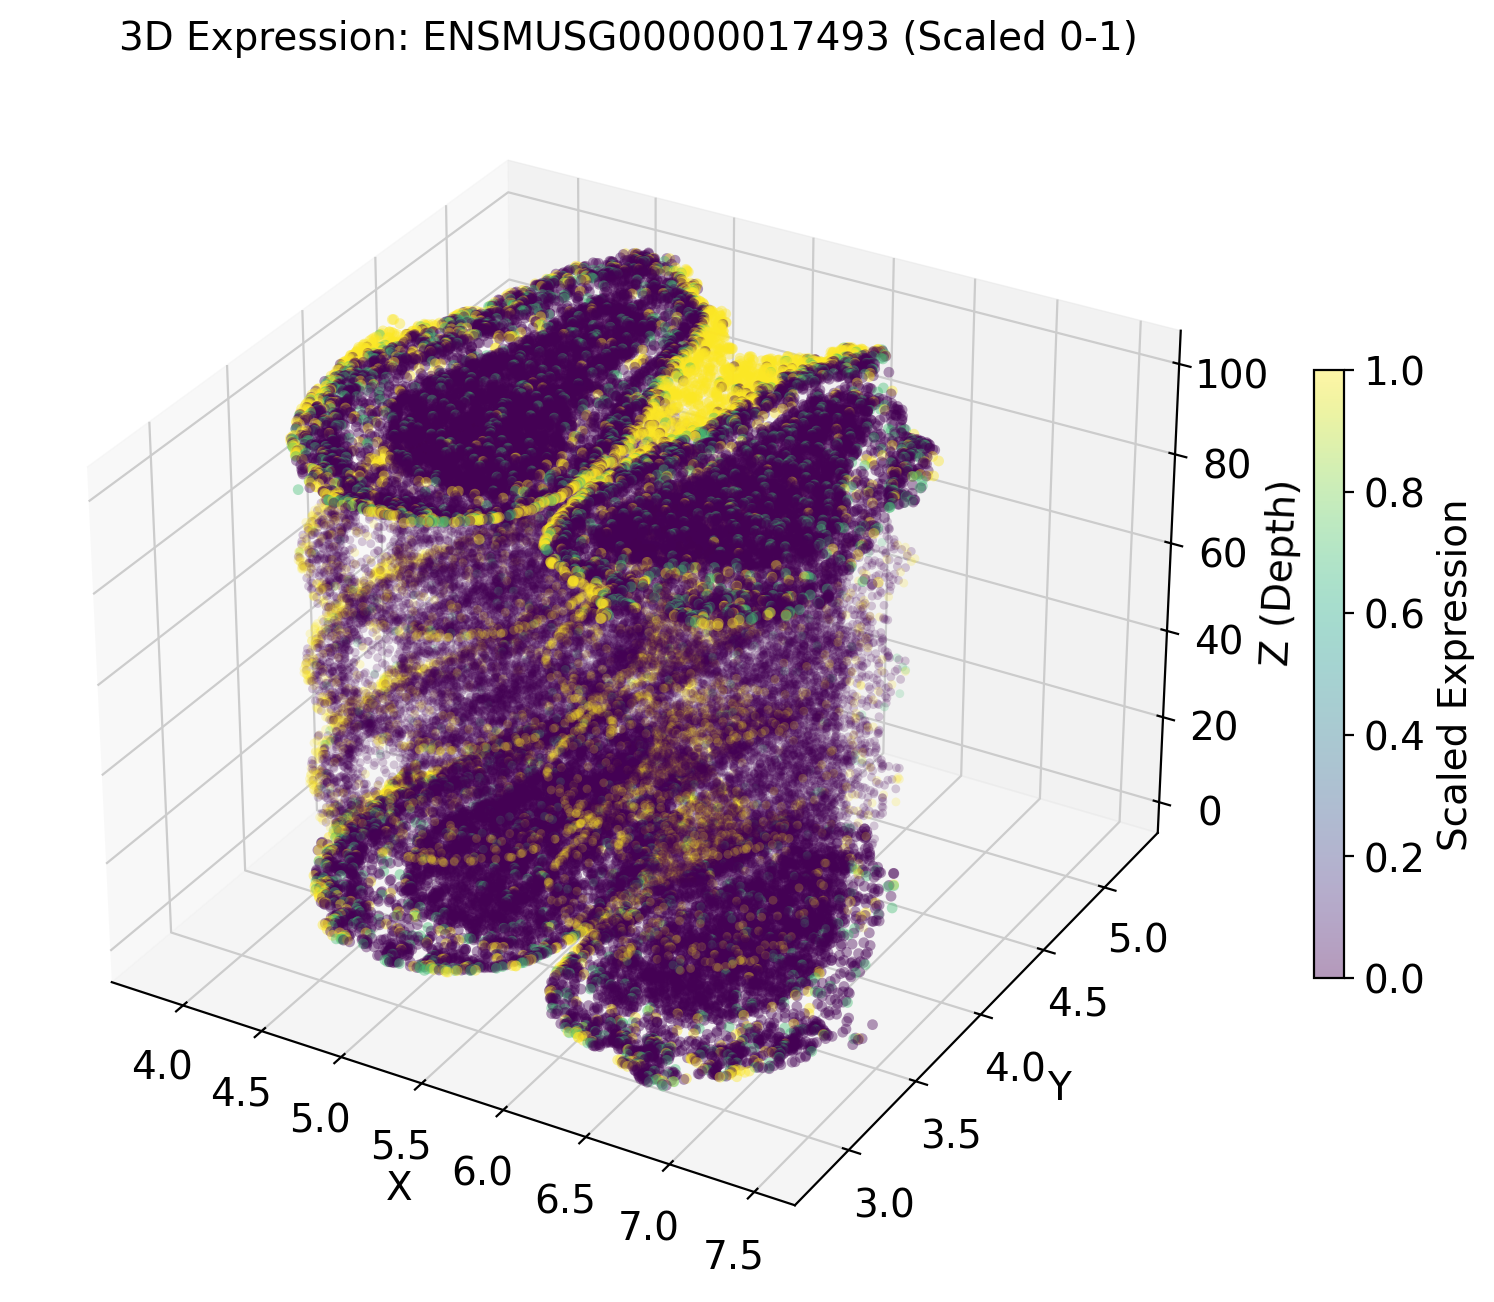

In [56]:
def plot_gene_3d(all_slices, slice_metadata, gene_name):
    """Plot a single gene in 3D across all slices."""
    if gene_name not in all_slices[0].var_names:
        print(f"Gene {gene_name} not found in dataset.")
        return

    # Collect all expression values to find global min/max for scaling
    all_expr = []
    for slice_data in all_slices:
        sc.pp.log1p(slice_data)  # Ensure log1p is applied
        gene_idx = list(slice_data.var_names).index(gene_name)

        X = slice_data.X.toarray() if hasattr(slice_data.X, 'toarray') else slice_data.X
        all_expr.append(X[:, gene_idx])
    
    # global_min = np.min(np.concatenate(all_expr))
    # global_max = np.max(np.concatenate(all_expr))

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    for slice_data, metadata in zip(all_slices, slice_metadata):
        # Get expression
        gene_idx = list(slice_data.var_names).index(gene_name)
        X = slice_data.X.toarray() if hasattr(slice_data.X, 'toarray') else slice_data.X
        expr = X[:, gene_idx]
        
        # # Scale to 0-1
        # if global_max > global_min:
        #     expr = (expr - global_min) / (global_max - global_min)
    

        coords = slice_data.obsm['spatial']
        z = np.full(len(coords), metadata['z'])
        
        # Style based on type
        alpha = 0.4 if metadata['type'] == 'reference' else 0.2
        size = 15 if metadata['type'] == 'reference' else 10
        
        p = ax.scatter(coords[:, 0], coords[:, 1], z, c=expr, cmap='viridis', 
                        s=size, alpha=alpha, linewidth=0, vmin=0, vmax=1)
            
    ax.set_title(f"3D Expression: {gene_name} (Scaled 0-1)")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z (Depth)")
    plt.colorbar(p, label='Scaled Expression', shrink=0.5)
    plt.show()

plot_gene_3d(all_slices, slice_metadata, "ENSMUSG00000017493")

## 6. Evaluation

We evaluate the quality of interpolation using the **Gene Continuity Score**. This metric measures how smoothly gene expression changes across the interpolated Z-axis.

Interpolation Performance (Continuity Score):
----------------------------------------
ENSMUSG00000017493: 0.9495


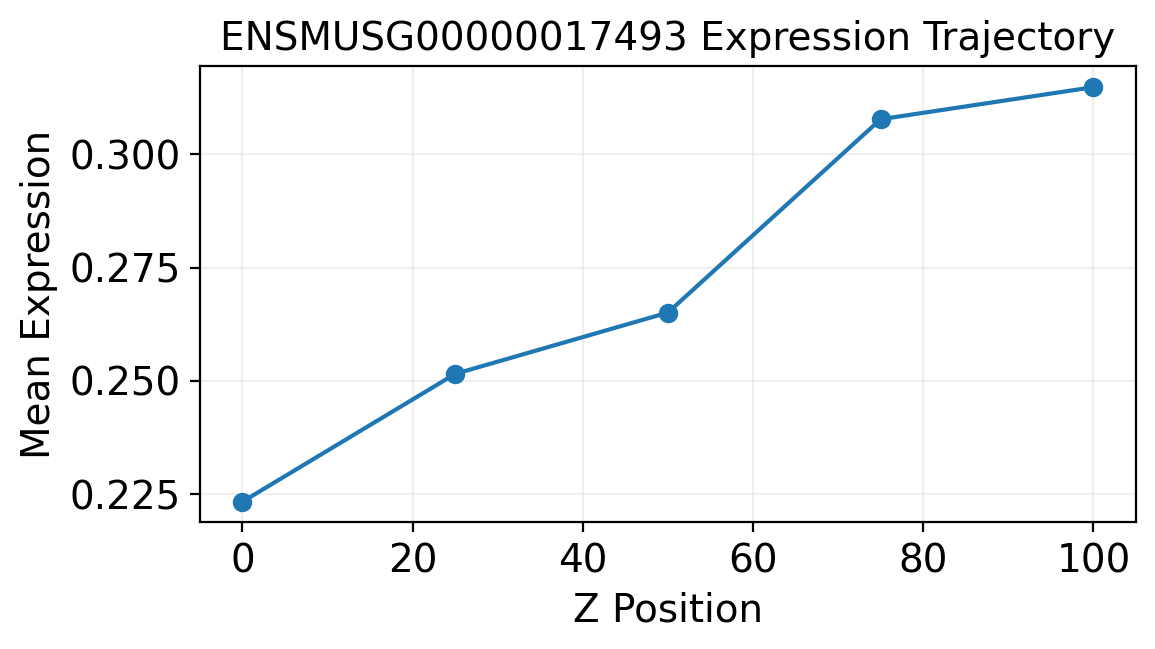

In [57]:
def calculate_continuity(all_slices, slice_metadata, gene_name):
    """Calculate continuity score for a gene."""
    means = []
    for slice_data in all_slices:
        if gene_name in slice_data.var_names:
            gene_idx = list(slice_data.var_names).index(gene_name)
            X = slice_data.X.toarray() if hasattr(slice_data.X, 'toarray') else slice_data.X
            means.append(X[:, gene_idx].mean())
            
    means = np.array(means)
    if len(means) < 2 or np.mean(means) == 0:
        return 0.0
        
    # Continuity = 1 - (std of differences / mean expression)
    score = 1.0 - np.std(np.diff(means)) / np.mean(means)
    return score, means

genes_to_check = ["ENSMUSG00000017493"]

print("Interpolation Performance (Continuity Score):")
print("-" * 40)

for gene in genes_to_check:
    score, means = calculate_continuity(all_slices, slice_metadata, gene)
    print(f"{gene}: {score:.4f}")
    
    # Optional: Plot the mean expression trajectory
    plt.figure(figsize=(6, 3))
    z_vals = [m['z'] for m in slice_metadata]
    plt.plot(z_vals, means, 'o-', label=gene)
    plt.title(f"{gene} Expression Trajectory")
    plt.xlabel("Z Position")
    plt.ylabel("Mean Expression")
    plt.grid(True, alpha=0.3)
    plt.show()